In [78]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import contextily as ctx
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize']=(12,4)

import sys
sys.path.append('../src/streaming/3dep/')
from get_als import get_nearest_year_product

In [163]:
vb['top_classifications']

0         [{'cc_code': 'cc.46260', 'ci_code': 'ci.297', ...
1         [{'cc_code': 'cc.47167', 'ci_code': 'ci.298', ...
2         [{'cc_code': 'cc.47130', 'ci_code': 'ci.299', ...
3         [{'cc_code': 'cc.47057', 'ci_code': 'ci.300', ...
4                                                      None
                                ...                        
138834    [{'cc_code': 'cc.62431', 'ci_code': 'ci.164146...
138835    [{'cc_code': 'cc.59022', 'ci_code': 'ci.164147...
138836    [{'cc_code': 'cc.62431', 'ci_code': 'ci.164148...
138837    [{'cc_code': 'cc.54585', 'ci_code': 'ci.167590...
138838    [{'cc_code': 'cc.63251', 'ci_code': 'ci.167591...
Name: top_classifications, Length: 138839, dtype: object

In [133]:
df=pd.read_parquet('../datasets/raw/vegbank/vegbank_plot_observations_nested.parquet')
df['community1']=df.apply(lambda x: x['top_classifications'][0]['comm_code'] if x['top_classifications'] is not None and len(x['top_classifications']) > 0 else None, axis=1)
df['comm1_name']=df.apply(lambda x: x['top_classifications'][0]['comm_name'] if x['top_classifications'] is not None and len(x['top_classifications']) > 0 else None, axis=1)

vb= gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["longitude"], df["latitude"]
    ),
    crs="EPSG:4326",
)
vb['year']=vb['year'].apply(lambda x: x if 1800<x<2026 else None) # filter out bad years


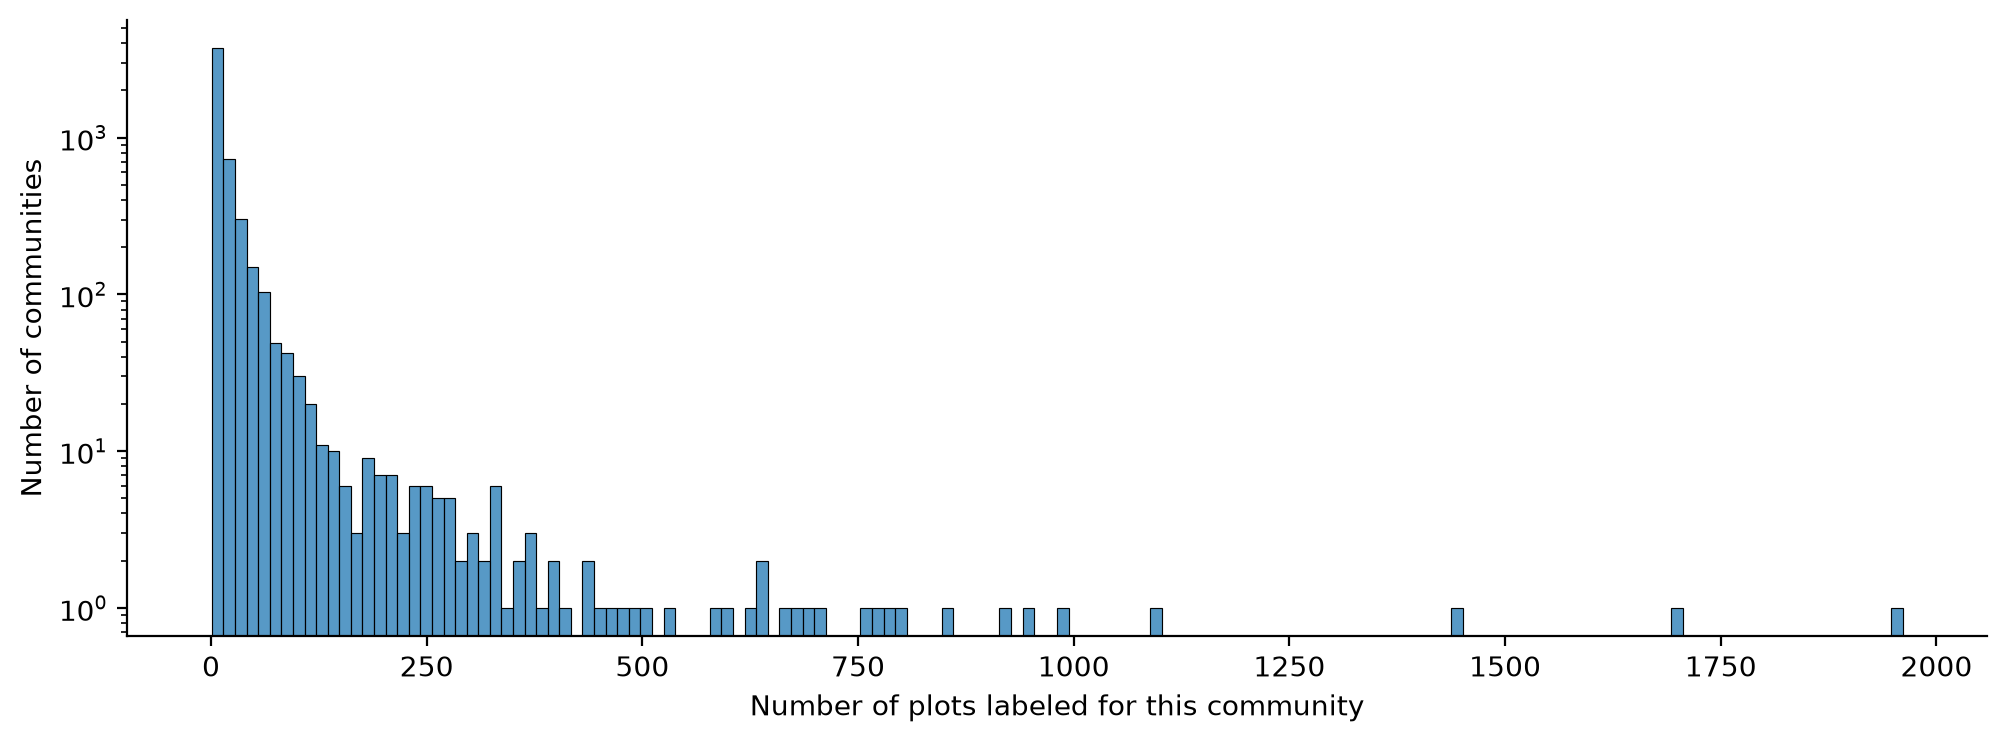

In [91]:
sns.histplot(vb['comm1_name'].value_counts())
plt.ylabel('Number of communities')
plt.xlabel('Number of plots labeled for this community')
plt.semilogy()
sns.despine()

In [92]:
# community types with at least N plots:
{n:sum(vb.comm1_name.value_counts()>n) for n in [1,10, 25, 50, 100]}

{1: 4417, 10: 1983, 25: 899, 50: 411, 100: 166}

In [93]:
# subset to common communities
comms = vb.comm1_name.value_counts().head(20).index
subset = vb[vb.comm1_name.isin(comms)]
# sample up to 100 plots per community
sampled = subset.groupby('comm1_name').sample(n=100)

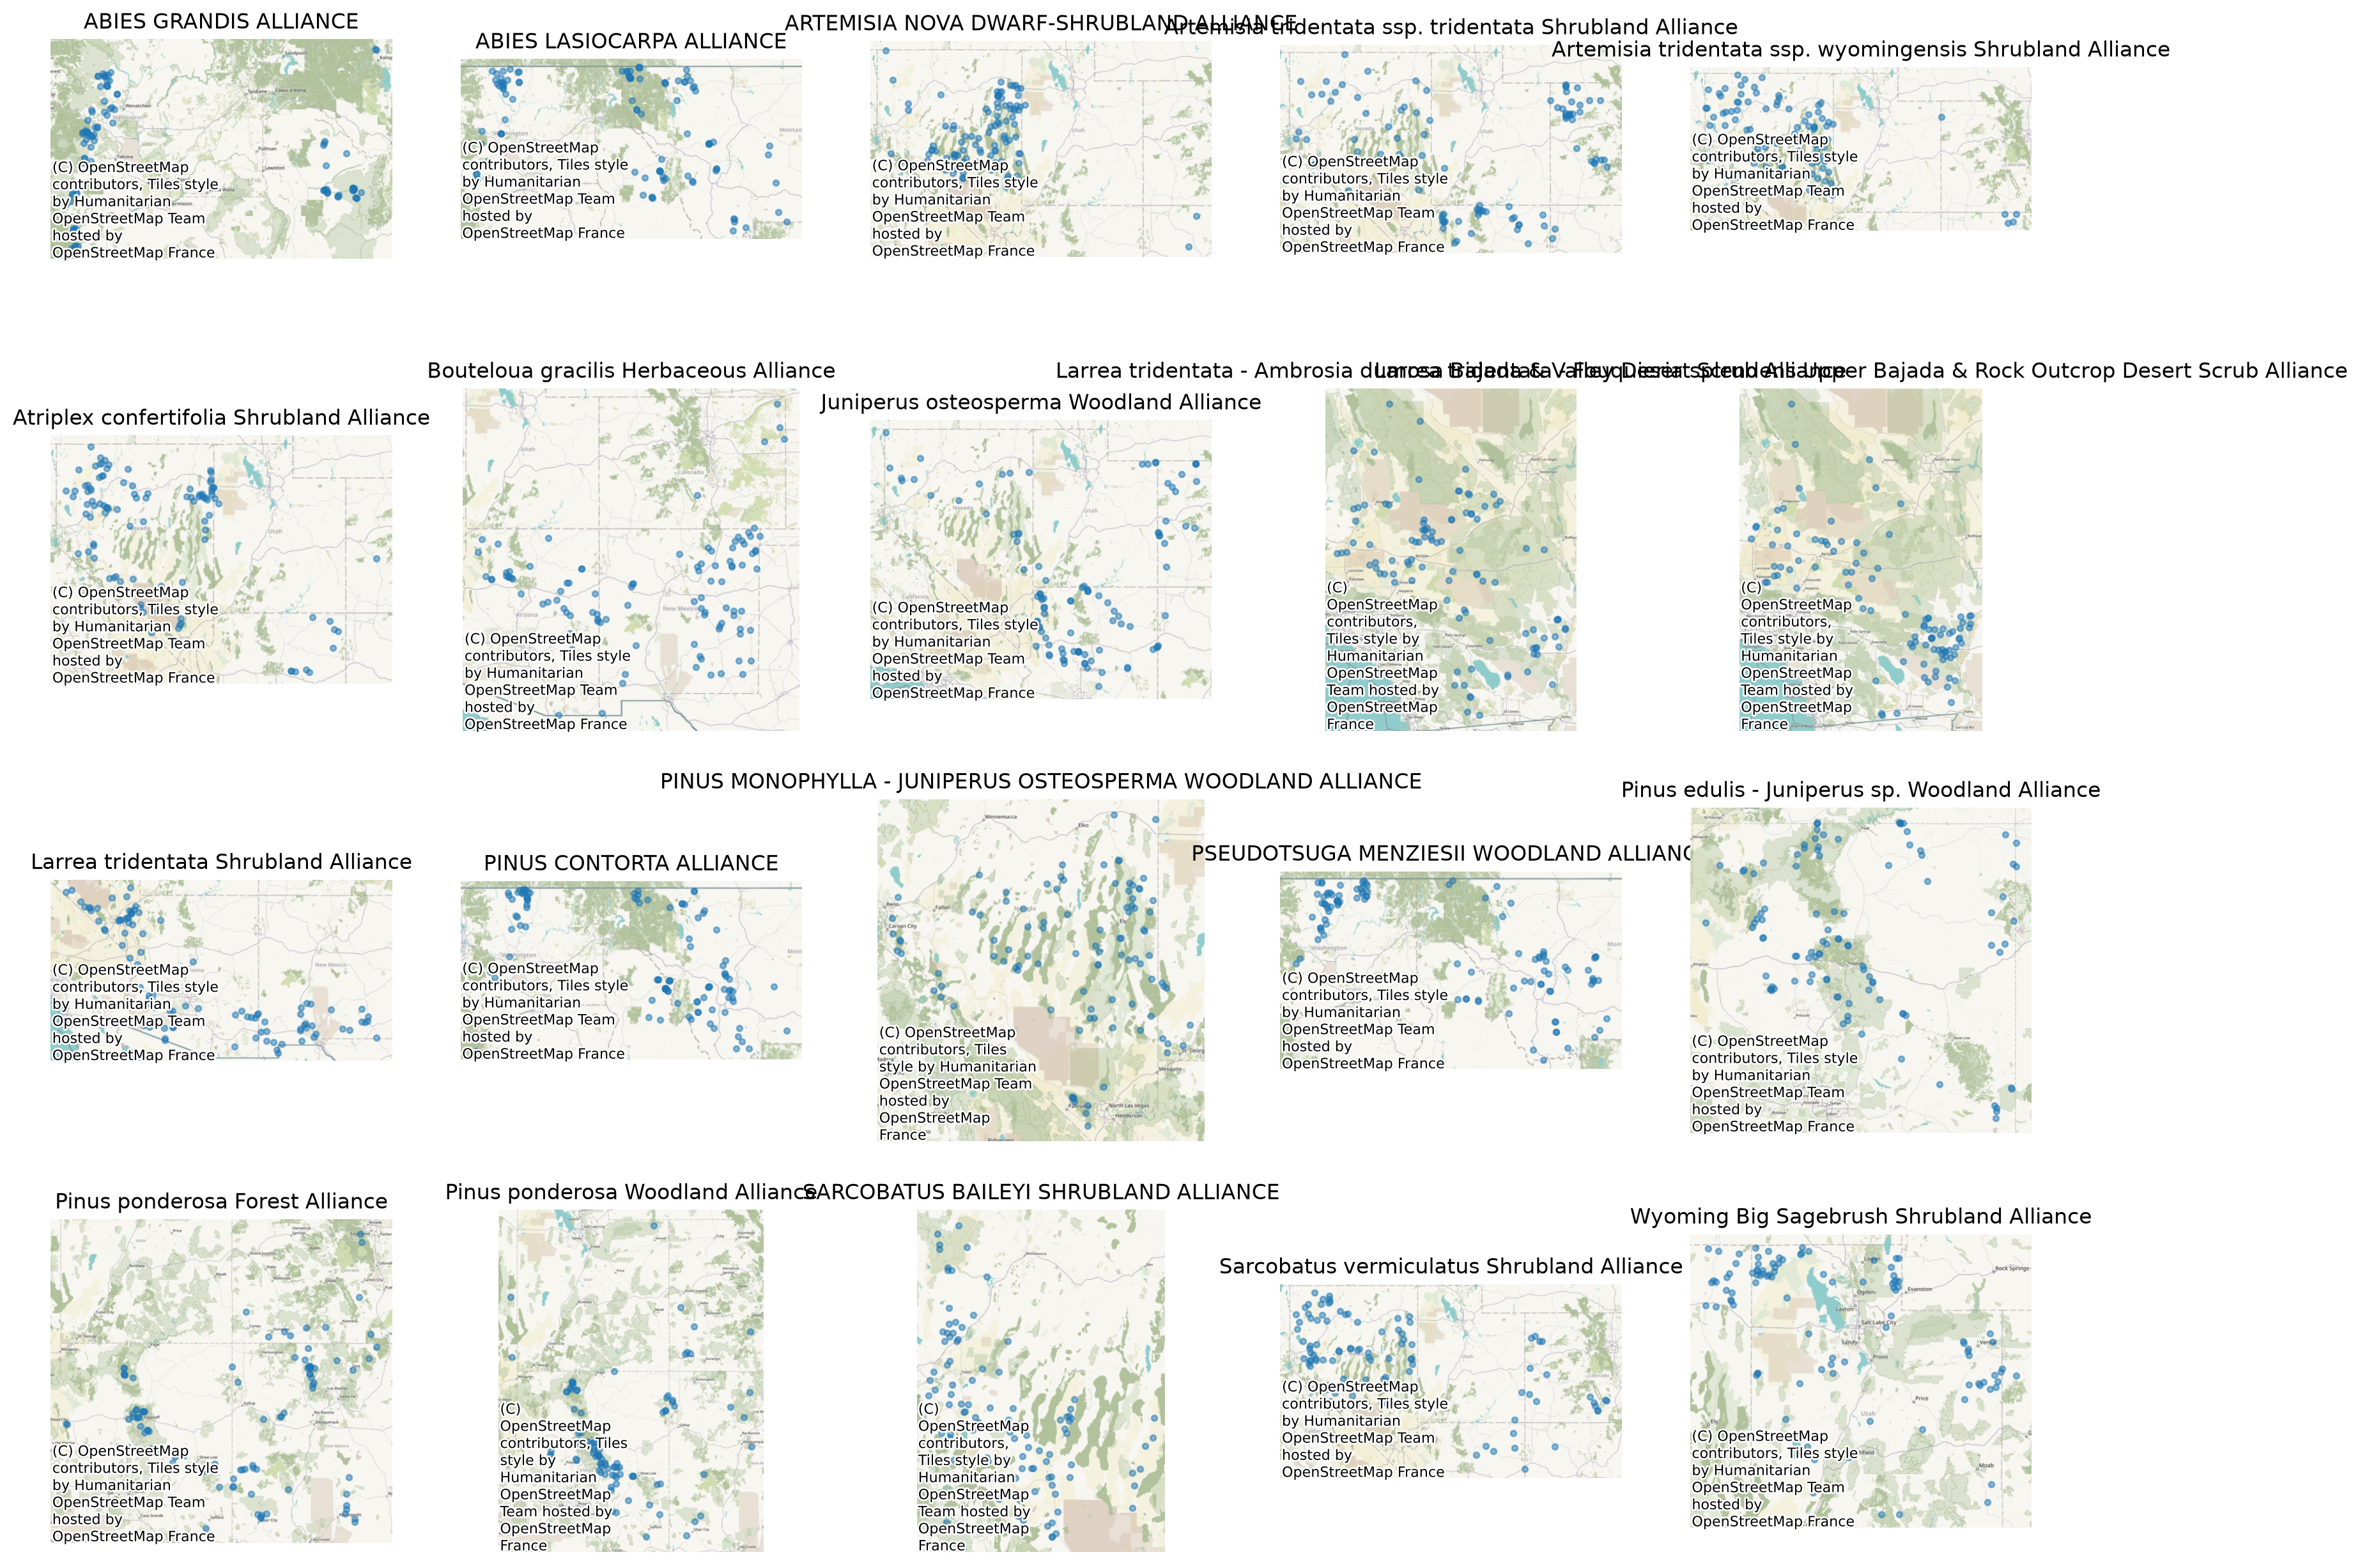

In [94]:
# draw separate maps with scatterplots of each community
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
for ax, (comm, group) in zip(axes.flatten(), sampled.groupby('comm1_name')):
    if len(group)>200:
        group = group.sample(n=200)
    group.plot(ax=ax, markersize=10, alpha=0.5)
    ax.set_title(comm)
    ax.set_axis_off()
    ctx.add_basemap(ax, crs=group.crs.to_string())

pair with lidar

In [122]:
def find(row):
    try:
        result = get_nearest_year_product(row['latitude'], row['longitude'],int(row['year']) )
        assert result is not None, "No product found"
        return result
    except Exception as e:
        return {'product_name_AWS': None, 'collection_year_AWS': None, 'year_diff_AWS': None}

In [ ]:
matched_als = vb.apply(find, axis=1, result_type='expand')
vb=vb.join(matched_als)

In [ ]:
# unique code for each plot (each unique coordinate pair is considered one plot)
plots = vb[['geometry']].drop_duplicates()
plots['plot_id']=range(len(plots))
# select 20% of plots for validation?
val_plots = plots.sample(frac=0.2, random_state=20260914)
plots['val_split'] = plots['plot_id'].isin(val_plots['plot_id'])
vb = vb.join(plots.set_index('geometry'), on='geometry', how='left')

,ob_code,author_obs_code,pl_code,author_plot_code,pj_code,project_name,rf_code,rf_label,has_observation_synonym,replaced_by_ob_code,...,soils,named_places,community1,comm1_name,geometry,product_name_AWS,collection_year_AWS,year_diff_AWS,plot_id,val_split
0,ob.2948,ACAD.143,pl.3004,ACAD.143,pj.340,Acadia National Park,NaN,NaN,False,None,...,"[{'base_saturation': None, 'clay': None, 'coar...","[{'code': 'n-us-me', 'description': None, 'nam...",CEGL005094,Vaccinium angustifolium - Sorbus americana / S...,POINT (-68.22934 44.34651),ME_MidCoast_1_2021,2021.0,23.0,0,False
1,ob.2949,ACAD.144,pl.3005,ACAD.144,pj.340,Acadia National Park,NaN,NaN,False,None,...,"[{'base_saturation': None, 'clay': None, 'coar...","[{'code': 'n-us-me', 'description': None, 'nam...",CEGL006153,"Typha (angustifolia, latifolia) - (Schoenoplec...",POINT (-68.22705 44.34002),ME_MidCoast_1_2021,2021.0,23.0,1,False
2,ob.2950,ACAD.145,pl.3006,ACAD.145,pj.340,Acadia National Park,NaN,NaN,False,None,...,"[{'base_saturation': None, 'clay': None, 'coar...","[{'code': 'TME0863', 'description': 'Maine, So...",CEGL006116,Pinus rigida / (Quercus ilicifolia) / Aronia m...,POINT (-68.22715 44.33958),ME_MidCoast_1_2021,2021.0,23.0,2,False
3,ob.2951,ACAD.146,pl.3007,ACAD.146,pj.340,Acadia National Park,NaN,NaN,False,None,...,"[{'base_saturation': None, 'clay': None, 'coar...","[{'code': 'TME0863', 'description': 'Maine, So...",CEGL006041,Pinus banksiana / Kalmia angustifolia - Vaccin...,POINT (-68.22415 44.33581),ME_MidCoast_1_2021,2021.0,23.0,3,True
4,ob.2952,ACAD.147,pl.3008,ACAD.147,pj.340,Acadia National Park,NaN,NaN,False,None,...,"[{'base_saturation': None, 'clay': None, 'coar...","[{'code': 'n-us-me', 'description': None, 'nam...",NaN,NaN,POINT (-68.28718 44.32738),ME_MidCoast_1_2021,2021.0,23.0,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138834,ob.260926,OVAA08138,pl.263113,OVAA08138,pj.11306,Owens Valley,NaN,NaN,False,None,...,None,None,A3880,Suaeda moquinii - Salicornia rubra - Isocoma a...,POINT (-117.95042 36.54261),NaN,NaN,NaN,110845,False
138835,ob.260927,OVAA08225,pl.263114,OVAA08225,pj.11306,Owens Valley,NaN,NaN,False,None,...,None,None,A3174,Atriplex polycarpa Scrub Alliance,POINT (-118.10581 36.7849),NaN,NaN,NaN,110846,False
138836,ob.260928,OVAA09474_2,pl.263115,OVAA09474_2,pj.11306,Owens Valley,NaN,NaN,False,None,...,None,None,A3880,Suaeda moquinii - Salicornia rubra - Isocoma a...,POINT (-117.884 36.37798),NaN,NaN,NaN,110847,False
138837,ob.260929,1A08069,pl.263116,1A08069,pj.11341,Sierra Nevada Foothills - North,NaN,NaN,False,None,...,None,None,A3346,Quercus agrifolia Woodland Alliance,POINT (-122.02516 40.48235),CA_CarrHirzDeltaFires_2_2019,2019.0,11.0,110848,False


In [118]:
# number of plots with lidar within N years of survey
{n:int((vb.year_diff_AWS<=n).sum()) for n in [1,3,5,10]}

{1: 4542, 3: 8884, 5: 13146, 10: 25838}

In [138]:
# filter to plots with lidar within 3 years of survey
filtered = vb[vb.year_diff_AWS<=3]

In [145]:
# explore 3-year filtered
filtered.groupby(['comm1_name','val_split']).size().unstack().rename(columns={0: 'train', 1: 'val'}).sort_values(by='train', ascending=False)

val_split,train,val
comm1_name,,
Quercus douglasii - Quercus wislizeni - Pinus sabiniana Woodland Alliance,139.0,31.0
Pseudotsuga macrocarpa – Quercus chrysolepis Association,67.0,17.0
Larrea tridentata - Fouquieria splendens Upper Bajada & Rock Outcrop Desert Scrub Alliance,46.0,18.0
Larrea tridentata - Ambrosia dumosa Bajada & Valley Desert Scrub Alliance,41.0,11.0
Adenostoma fasciculatum Chaparral Alliance,41.0,7.0
...,...,...
Sesuvium verrucosum – Distichlis spicata,NaN,1.0
Spartium junceum,NaN,1.0
Thermopsis californica – Bromus carinatus – Annual Brome,NaN,2.0


In [148]:
# number of communitity types with at least N training-set plots in the filtered dataset
{n:sum(filtered[filtered.val_split==0].comm1_name.value_counts()>n) for n in [1,10, 25, 50, 100]}

{1: 842, 10: 127, 25: 22, 50: 2, 100: 1}

In [154]:
# check turnover: how consistent are the community labels when multiple surveys occur at same location
from tqdm.autonotebook import tqdm
pairwise_community_change = []
pairwise_time_delta = []
for plot_id, group in tqdm(vb.groupby('plot_id')):
    if len(group)<2:
        continue
    group = group.sort_values(by='year')
    pairwise_time_delta.extend(group['year'].diff().iloc[1:])
    pairwise_community_change.extend(group['comm1_name'].ne(group['comm1_name'].shift()).iloc[1:])


/var/folders/_1/clc139q504qfy1s2zl7qf9h00000gr/T/ipykernel_40472/2198044810.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/110850 [00:00<?, ?it/s]

change in community type is very common: 61% of plots at the same location change community type at least once

In [157]:
np.array(pairwise_time_delta)

array([0., 0., 0., ..., 0., 0., 0.], shape=(27989,))

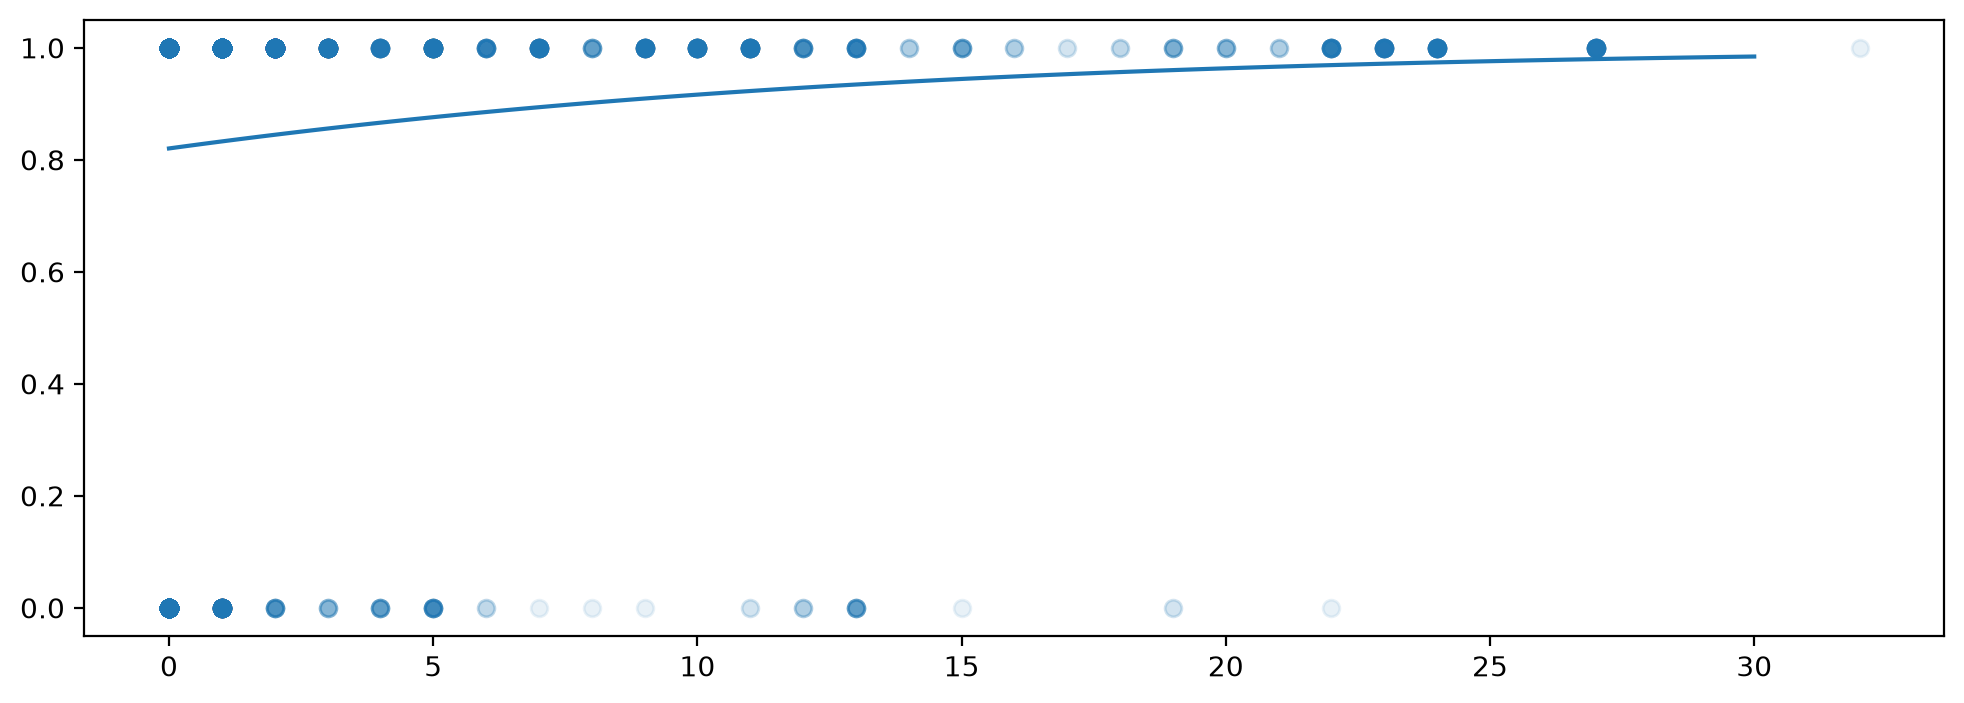

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# fit logistic curve
X = np.array(pairwise_time_delta).reshape(-1, 1)
y = np.array(pairwise_community_change)

# drop nans
mask = ~np.isnan(X).flatten() & ~np.isnan(y)
X = X[mask]
y = y[mask]

model = LogisticRegression()
model.fit(X, y)

x_pred = np.linspace(0, 30, 100).reshape(-1, 1)
y_pred = model.predict_proba(x_pred)[:, 1]
plt.plot(x_pred, y_pred)

# plot the data
plt.scatter(X, y, alpha=0.1)

let's see if I can visually distinguish the communities? 